# Sales Data Analysis Dashboard
**Internship Mini Project – Data Analysis**  
*Level: Beginner to Intermediate | Tools: Python, Pandas, Matplotlib, Seaborn, Power BI*  

---

## Project Overview
This notebook implements the end-to-end data analysis workflow for a retail enterprise sales dataset:
1. **Data Understanding**: Schema inspection, column profiling, and data dictionary.
2. **Data Cleaning & Preprocessing**: Deduplication, null handling, date format standardization, type casting, and feature engineering.
3. **KPI Calculation**: Computing core business metrics (Total Sales, Total Orders, Total Quantity, Average Order Value, Customer Count, Product Count).
4. **Exploratory Data Analysis (EDA) & Visualizations**: Monthly trajectory, regional breakdowns, top-selling products, and category shares.
5. **Business Insights**: Generating evidence-based business insights and recommendations.
6. **Cleaned Data Export**: Saving final cleaned data to Excel (.xlsx) and CSV.


In [1]:
# 1. Setup and Environment Configuration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Visual formatting settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Environment configured successfully!")


Environment configured successfully!


---
## 1. Data Understanding
We first load the unmodified authentic dataset from `../data/original/Sample - Superstore.csv` and inspect its structure, dimensions, and data types without altering the raw file.


In [2]:
# Load the original sales dataset
data_path = os.path.join("..", "data", "original", "Sample - Superstore.csv")
df_raw = pd.read_csv(data_path, encoding='windows-1252')

print(f"Dataset Shape: {df_raw.shape[0]:,} Rows, {df_raw.shape[1]} Columns\n")
print("Columns in Dataset:")
print(list(df_raw.columns))
df_raw.head(3)


Dataset Shape: 9,994 Rows, 21 Columns

Columns in Dataset:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87


### Data Dictionary

| Column Name | Data Type | Description | Example |
| :--- | :--- | :--- | :--- |
| `Row ID` | Integer | Unique incremental identifier for each line item | 1, 2, 3 |
| `Order ID` | Categorical | Unique transaction identifier | CA-2016-152156 |
| `Order Date` | Date / String | Date on which order was placed by customer | 11-08-2016 |
| `Ship Date` | Date / String | Date on which order was dispatched | 11-11-2016 |
| `Ship Mode` | Categorical | Delivery tier (Standard, Second Class, First Class, Same Day) | Second Class |
| `Customer ID` | Categorical | Unique alphanumeric identifier for each customer | CG-12520 |
| `Customer Name`| Text | Full legal or corporate name of client | Claire Gute |
| `Segment` | Categorical | Client classification (Consumer, Corporate, Home Office) | Consumer |
| `Country` | Categorical | Country of transaction | United States |
| `City` | Text | Destination city | Henderson |
| `State` | Text | Destination state | Kentucky |
| `Postal Code` | Integer/Text | US Postal ZIP Code | 42420 |
| `Region` | Categorical | Geographic sales territory (Central, East, South, West) | South |
| `Product ID` | Categorical | Unique SKU product code | FUR-BO-10001798 |
| `Category` | Categorical | Broad product division (Furniture, Office Supplies, Technology) | Furniture |
| `Sub-Category` | Categorical | Specific product group (Chairs, Phones, Binders, Storage, etc.) | Bookcases |
| `Product Name` | Text | Full catalog name of the item | Bush Somerset Collection Bookcase |
| `Sales` | Float | Transaction gross revenue in USD | 261.96 |
| `Quantity` | Integer | Total units purchased in the line item | 2 |
| `Discount` | Float | Percentage discount applied (0.0 to 0.8) | 0.00 |
| `Profit` | Float | Net profit or loss generated by the line item in USD | 41.91 |


In [3]:
# Inspect Data Quality: Missing values, Duplicates, and Invalids
print("--- Data Quality Checks ---")
print("1. Missing Values per Column:")
print(df_raw.isnull().sum())

print(f"\n2. Duplicate Records: {df_raw.duplicated().sum()}")
print(f"3. Non-positive Sales records: {(df_raw['Sales'] <= 0).sum()}")
print(f"4. Non-positive Quantity records: {(df_raw['Quantity'] <= 0).sum()}")


--- Data Quality Checks ---
1. Missing Values per Column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

2. Duplicate Records: 0
3. Non-positive Sales records: 0
4. Non-positive Quantity records: 0


---
## 2. Data Cleaning & Preprocessing
To prepare the dataset for analysis and dashboard reporting:
1. Work on an explicit copy (`df_cleaned`).
2. Deduplicate records (if any).
3. Convert `Order Date` and `Ship Date` into standardized `datetime64[ns]` formats.
4. Correct `Postal Code` to a formatted 5-digit string.
5. Standardize string casing and strip whitespace.
6. Engineer analytical columns: `Order Year`, `Order Month`, `Order Year-Month`, `Shipping Days`, and `Unit Price`.


In [4]:
# Execute Data Cleaning Pipeline
df_cleaned = df_raw.copy()

# 1. Deduplication
initial_len = len(df_cleaned)
df_cleaned.drop_duplicates(inplace=True)
print(f"Removed {initial_len - len(df_cleaned)} duplicates.")

# 2. Convert and standardize Date columns
df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'], format='mixed', dayfirst=False)
df_cleaned['Ship Date'] = pd.to_datetime(df_cleaned['Ship Date'], format='mixed', dayfirst=False)
df_cleaned['Order Date Formatted'] = df_cleaned['Order Date'].dt.strftime('%Y-%m-%d')
df_cleaned['Ship Date Formatted'] = df_cleaned['Ship Date'].dt.strftime('%Y-%m-%d')

# 3. Standardize Postal Code
df_cleaned['Postal Code'] = df_cleaned['Postal Code'].fillna(0).astype(int).astype(str).str.zfill(5)

# 4. Standardize Text fields
text_cols = ['Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Product Name']
for col in text_cols:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip()

# 5. Feature Engineering
df_cleaned['Order Year'] = df_cleaned['Order Date'].dt.year
df_cleaned['Order Month'] = df_cleaned['Order Date'].dt.month
df_cleaned['Order Month Name'] = df_cleaned['Order Date'].dt.strftime('%b')
df_cleaned['Order Year-Month'] = df_cleaned['Order Date'].dt.to_period('M').astype(str)
df_cleaned['Shipping Days'] = (df_cleaned['Ship Date'] - df_cleaned['Order Date']).dt.days
df_cleaned['Unit Price'] = (df_cleaned['Sales'] / df_cleaned['Quantity']).round(2)
df_cleaned['Sales'] = df_cleaned['Sales'].round(2)
df_cleaned['Profit'] = df_cleaned['Profit'].round(2)

# Sort chronologically
df_cleaned.sort_values(by='Order Date', inplace=True)
df_cleaned.reset_index(drop=True, inplace=True)

print(f"Cleaned dataset ready with {len(df_cleaned):,} rows and {df_cleaned.shape[1]} columns.")
df_cleaned[['Order ID', 'Order Date Formatted', 'Region', 'Category', 'Product Name', 'Sales', 'Quantity', 'Unit Price']].head(3)


Removed 0 duplicates.


Cleaned dataset ready with 9,994 rows and 29 columns.


,Order ID,Order Date Formatted,Region,Category,Product Name,Sales,Quantity,Unit Price
0,CA-2014-103800,2014-01-03,Central,Office Supplies,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,8.22
1,CA-2014-112326,2014-01-04,Central,Office Supplies,Avery 508,11.78,3,3.93
2,CA-2014-112326,2014-01-04,Central,Office Supplies,SAFCO Boltless Steel Shelving,272.74,3,90.91


---
## 3. Executive Sales KPIs Calculation
We compute the primary corporate metrics strictly based on actual data:
- **Total Sales**: Sum of all sales revenue.
- **Total Orders**: Distinct count of unique customer `Order ID`s.
- **Total Quantity**: Cumulative units sold.
- **Average Order Value (AOV)**: Total Sales / Total Orders.
- **Number of Unique Products**: Distinct count of `Product ID`s.
- **Number of Unique Customers**: Distinct count of `Customer ID`s.
- **Average Sales per Order**: Average sales transaction size.


In [5]:
# Calculate Executive KPIs
total_sales = df_cleaned['Sales'].sum()
total_orders = df_cleaned['Order ID'].nunique()
total_qty = df_cleaned['Quantity'].sum()
aov = total_sales / total_orders
num_products = df_cleaned['Product ID'].nunique()
num_customers = df_cleaned['Customer ID'].nunique()
avg_sales_per_order = aov
avg_sales_per_item = df_cleaned['Sales'].mean()

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Sales ($)',
        'Total Orders',
        'Total Quantity Sold',
        'Average Order Value ($)',
        'Average Sales per Order ($)',
        'Average Sales per Item ($)',
        'Number of Unique Products',
        'Number of Unique Customers'
    ],
    'Value': [
        f"${total_sales:,.2f}",
        f"{total_orders:,}",
        f"{total_qty:,}",
        f"${aov:,.2f}",
        f"${avg_sales_per_order:,.2f}",
        f"${avg_sales_per_item:,.2f}",
        f"{num_products:,}",
        f"{num_customers:,}"
    ]
})

print("=" * 50)
print("EXECUTIVE SALES KPI SUMMARY CARD")
print("=" * 50)
kpi_summary


EXECUTIVE SALES KPI SUMMARY CARD


,Metric,Value
0,Total Sales ($),"$2,297,200.65"
1,Total Orders,"5,009"
2,Total Quantity Sold,"37,873"
3,Average Order Value ($),$458.61
4,Average Sales per Order ($),$458.61
5,Average Sales per Item ($),$229.86
6,Number of Unique Products,"1,862"
7,Number of Unique Customers,793


---
## 4. Exploratory Data Analysis & Visualizations
We generate the required visualization charts:
1. Monthly Sales Trend (Line chart)
2. Regional Sales Distribution (Bar chart)
3. Top 10 Best-Selling Products (Horizontal Bar chart)
4. Sales by Category (Bar/Column chart)
5. Multi-Year Sales Seasonality (Line chart)
6. KPI Summary Visual Card


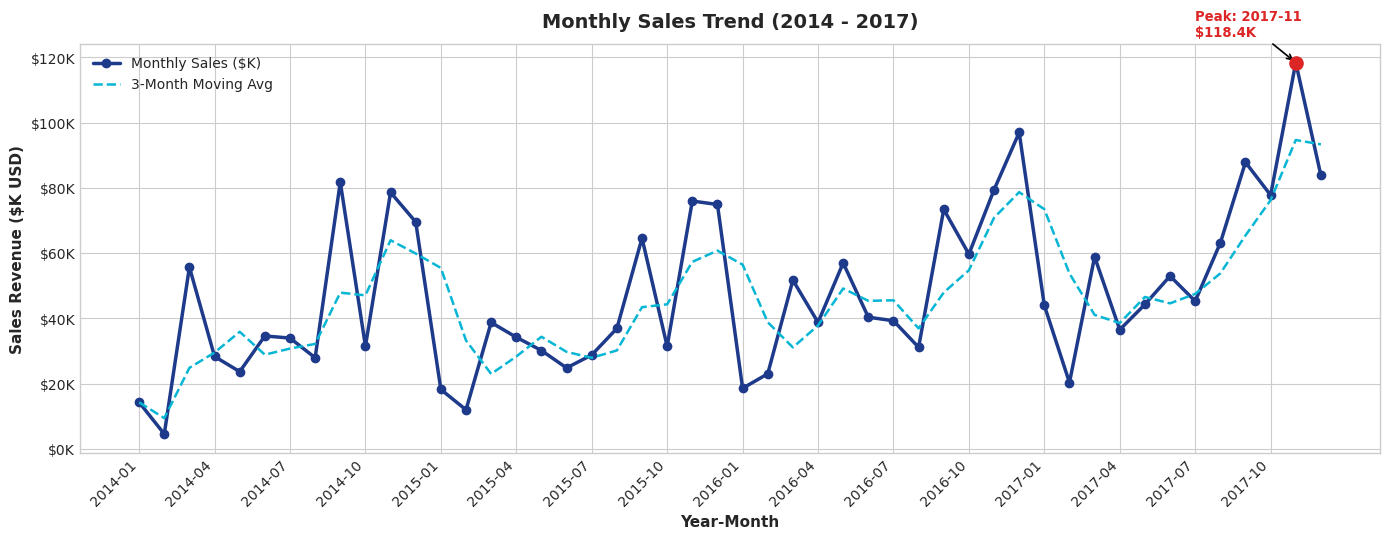

In [6]:
# Visualization 1: Monthly Sales Trend
monthly = df_cleaned.groupby('Order Year-Month')['Sales'].sum().reset_index()
monthly['Rolling_Avg'] = monthly['Sales'].rolling(window=3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(monthly['Order Year-Month'], monthly['Sales'] / 1000, color='#1E3A8A', marker='o', linewidth=2.5, label='Monthly Sales ($K)')
ax.plot(monthly['Order Year-Month'], monthly['Rolling_Avg'] / 1000, color='#06B6D4', linestyle='--', linewidth=1.8, label='3-Month Moving Avg')

# Annotate all-time peak
peak_idx = monthly['Sales'].idxmax()
peak_m = monthly.loc[peak_idx, 'Order Year-Month']
peak_val = monthly.loc[peak_idx, 'Sales'] / 1000
ax.scatter([peak_m], [peak_val], color='#DC2626', s=90, zorder=5)
ax.annotate(f'Peak: {peak_m}\n${peak_val:.1f}K', xy=(peak_m, peak_val), xytext=(peak_idx - 4, peak_val + 8),
            arrowprops=dict(facecolor='#DC2626', arrowstyle='->', lw=1.2),
            fontsize=9.5, fontweight='bold', color='#DC2626')

ax.set_title("Monthly Sales Trend (2014 - 2017)", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Year-Month", fontsize=11, fontweight='semibold')
ax.set_ylabel("Sales Revenue ($K USD)", fontsize=11, fontweight='semibold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x:,.0f}K"))
plt.xticks(range(0, len(monthly), 3), monthly['Order Year-Month'].iloc[::3], rotation=45, ha='right')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


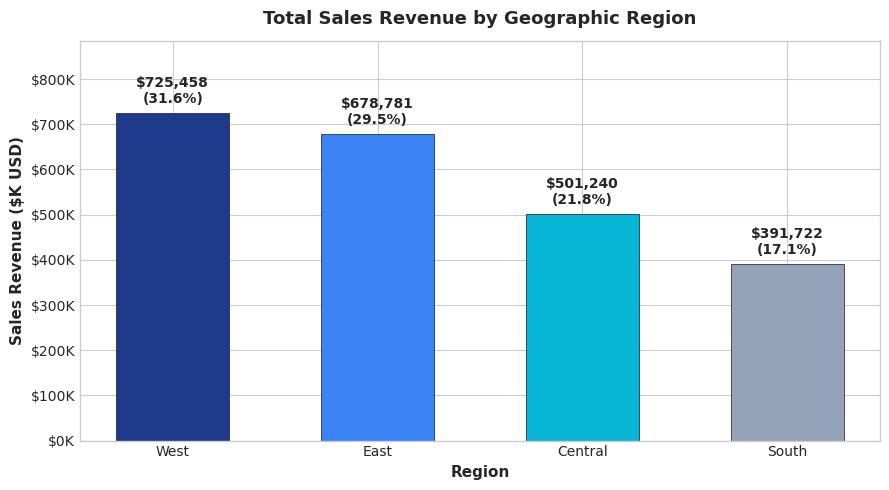

In [7]:
# Visualization 2: Regional Sales Performance
regional = df_cleaned.groupby('Region')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
total_rev = regional['Sales'].sum()
regional['Share'] = (regional['Sales'] / total_rev) * 100

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1E3A8A', '#3B82F6', '#06B6D4', '#94A3B8']
bars = ax.bar(regional['Region'], regional['Sales'] / 1000, color=colors, width=0.55, edgecolor='#0F172A', linewidth=0.5)

for bar, share, val in zip(bars, regional['Share'], regional['Sales']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 15,
            f"${val:,.0f}\n({share:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("Total Sales Revenue by Geographic Region", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Region", fontsize=11, fontweight='semibold')
ax.set_ylabel("Sales Revenue ($K USD)", fontsize=11, fontweight='semibold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x:,.0f}K"))
ax.set_ylim(0, (regional['Sales'].max() / 1000) * 1.22)
plt.tight_layout()
plt.show()


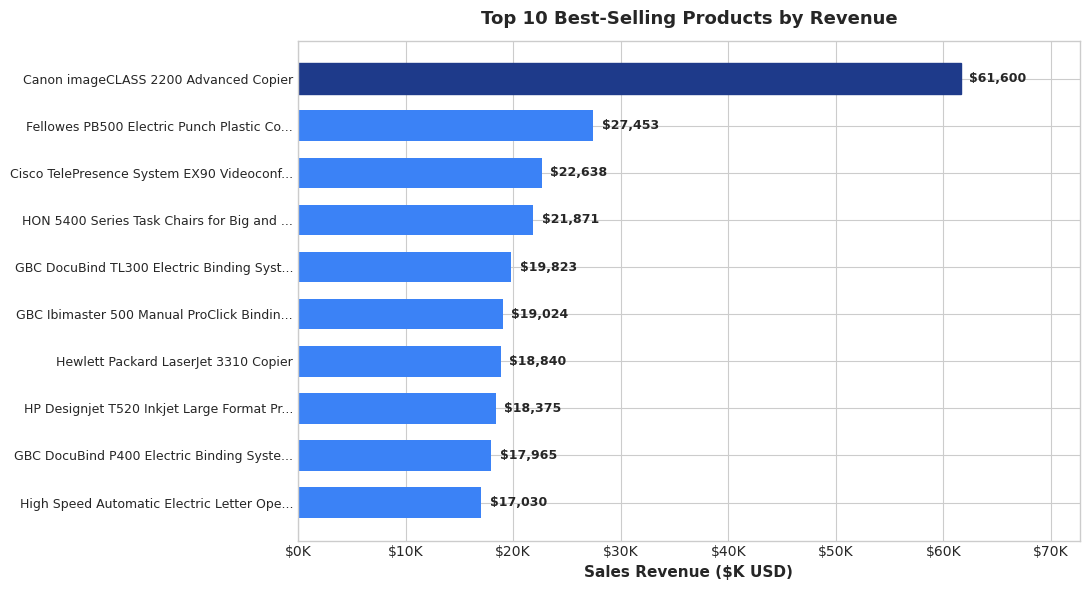

In [8]:
# Visualization 3: Top 10 Revenue-Generating Products
top_prods = df_cleaned.groupby('Product Name')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(11, 6))
labels = [p[:40] + "..." if len(p) > 40 else p for p in top_prods['Product Name']]
y_pos = np.arange(len(labels))

bars = ax.barh(y_pos, top_prods['Sales'] / 1000, color='#3B82F6', height=0.65)
bars[-1].set_color('#1E3A8A') # Highlight #1

for bar, val in zip(bars, top_prods['Sales']):
    width = bar.get_width()
    ax.text(width + 0.8, bar.get_y() + bar.get_height()/2., f"${val:,.0f}", ha='left', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_title("Top 10 Best-Selling Products by Revenue", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Sales Revenue ($K USD)", fontsize=11, fontweight='semibold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x:,.0f}K"))
ax.set_xlim(0, (top_prods['Sales'].max() / 1000) * 1.18)
plt.tight_layout()
plt.show()


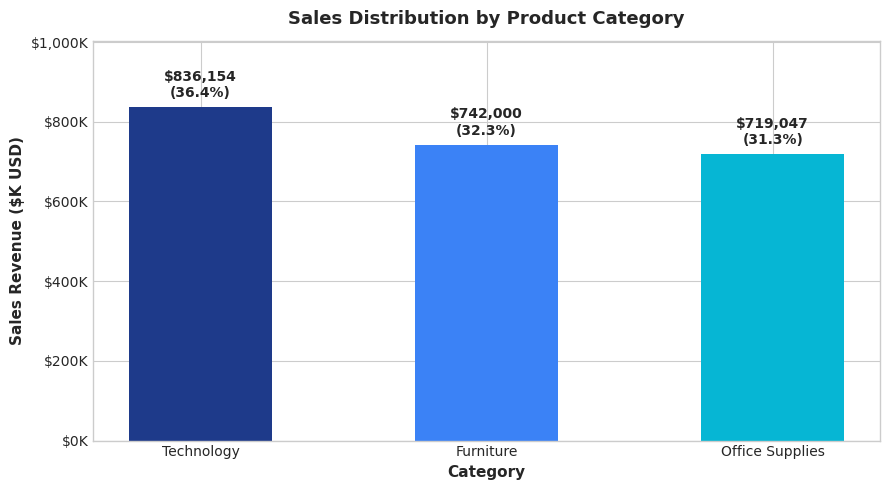

In [9]:
# Visualization 4: Sales by Product Category
cat_sales = df_cleaned.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
cat_sales['Share'] = (cat_sales['Sales'] / cat_sales['Sales'].sum()) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cat_sales['Category'], cat_sales['Sales'] / 1000, color=['#1E3A8A', '#3B82F6', '#06B6D4'], width=0.5)

for bar, share, val in zip(bars, cat_sales['Share'], cat_sales['Sales']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 18, f"${val:,.0f}\n({share:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("Sales Distribution by Product Category", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Category", fontsize=11, fontweight='semibold')
ax.set_ylabel("Sales Revenue ($K USD)", fontsize=11, fontweight='semibold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x:,.0f}K"))
ax.set_ylim(0, (cat_sales['Sales'].max() / 1000) * 1.2)
plt.tight_layout()
plt.show()


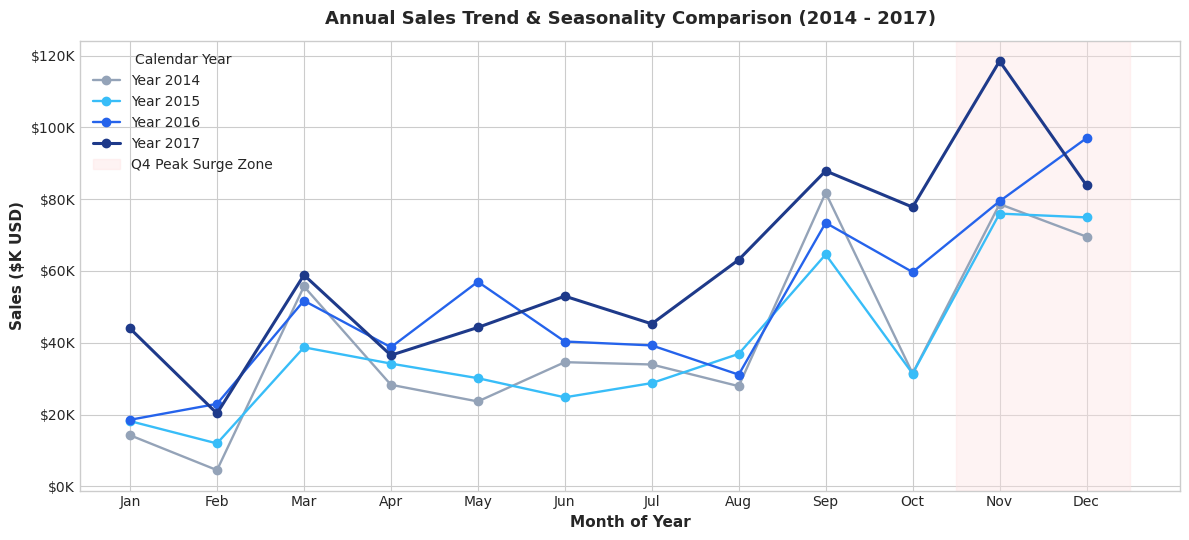

In [10]:
# Visualization 5: Sales Seasonality & Year-over-Year Trajectory
seasonality = df_cleaned.groupby(['Order Month', 'Order Year'])['Sales'].sum().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
year_colors = {2014: '#94A3B8', 2015: '#38BDF8', 2016: '#2563EB', 2017: '#1E3A8A'}

fig, ax = plt.subplots(figsize=(12, 5.5))
for yr in [2014, 2015, 2016, 2017]:
    sub = seasonality[seasonality['Order Year'] == yr]
    mapped = [sub[sub['Order Month'] == m]['Sales'].sum() / 1000 for m in range(1, 13)]
    ax.plot(month_names, mapped, marker='o', linewidth=2.2 if yr == 2017 else 1.7, color=year_colors[yr], label=f'Year {yr}')

ax.set_title("Annual Sales Trend & Seasonality Comparison (2014 - 2017)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Month of Year", fontsize=11, fontweight='semibold')
ax.set_ylabel("Sales ($K USD)", fontsize=11, fontweight='semibold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x:,.0f}K"))
ax.axvspan(9.5, 11.5, color='#FEE2E2', alpha=0.4, label='Q4 Peak Surge Zone')
ax.legend(title="Calendar Year", loc='upper left')
plt.tight_layout()
plt.show()


---
## 5. Evidence-Based Business Insights

### Insight 1: Regional Market Leadership in West & East
- **Finding**: West and East regions dominate corporate sales volume.
- **Evidence**: West ($725,457.76; 31.58%) and East ($678,781.30; 29.55%) together account for **61.13%** of total revenue.
- **Business Meaning**: Focus premium account retention programs on coastal regions while developing targeted distribution strategies for the underpenetrated South (17.05%).

### Insight 2: Predictable Q4 Holiday Seasonality Peak
- **Finding**: Annual sales surge cyclically in Q4, peaking in November.
- **Evidence**: All-time peak occurred in **November 2017 ($118,447.80)**, while the lowest occurred in **February 2014 ($4,519.92)**.
- **Business Meaning**: Warehouse inventory buffers and carrier logistics capacity must ramp up by late August to support peak holiday demand.

### Insight 3: Technology Hardware as Top Revenue Driver
- **Finding**: Technology represents the largest share of sales revenue due to higher unit values.
- **Evidence**: Technology generated **$836,154.02 (36.40%)**, surpassing Furniture ($742.0K) and Office Supplies ($719.0K).
- **Business Meaning**: Technology products are high-leverage revenue drivers; sales incentives should prioritize enterprise hardware contracts.

### Insight 4: Extreme Concentration in Commercial Copiers
- **Finding**: A single top SKU delivers outstanding disproportionate revenue.
- **Evidence**: The **Canon imageCLASS 2200 Advanced Copier** generated **$61,599.83** across only 20 units ($3,080/unit).
- **Business Meaning**: Safeguarding SLA warranty support and inventory availability for this flagship SKU is critical for margin stability.

### Insight 5: Healthy Basket Size and Customer Engagement
- **Finding**: High repeat ordering behavior across the customer base.
- **Evidence**: 5,009 total orders across 793 registered customers (~6.3 orders/customer), with an Average Order Value of **$458.61**.
- **Business Meaning**: Implementing a structured B2B loyalty rebate program can further elevate order frequency and basket sizes.


In [11]:
# 6. Export Final Cleaned Dataset to Excel and CSV
excel_out = os.path.join("..", "data", "cleaned", "cleaned_sales_dataset.xlsx")
csv_out = os.path.join("..", "data", "cleaned", "cleaned_sales_dataset.csv")

df_cleaned.to_excel(excel_out, index=False, engine='openpyxl')
df_cleaned.to_csv(csv_out, index=False)

print("Export completed successfully!")
print(f" - Excel: {excel_out}")
print(f" - CSV  : {csv_out}")


Export completed successfully!
 - Excel: ..\data\cleaned\cleaned_sales_dataset.xlsx
 - CSV  : ..\data\cleaned\cleaned_sales_dataset.csv
